# CSCE 636 – Project Checkpoint 2
## Research Question Formation

### Dymond Allen

---

## 1. Introduction

This project uses the **Online Retail dataset**, which contains transactional purchase data including products, quantities, timestamps, and customer identifiers.

The goal of this checkpoint is to:
- Define meaningful research questions based on exploratory data analysis (EDA)
- Map each question to appropriate data mining techniques
- Ensure that the proposed methods are feasible and well-justified

The dataset is well-suited for **market basket analysis** and **pattern mining** because it captures real-world retail transactions over time.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving online+retail.zip to online+retail.zip


In [4]:
import zipfile

with zipfile.ZipFile('online+retail.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [5]:
import os
os.listdir()

['.config', 'Online Retail.xlsx', 'online+retail.zip', 'sample_data']

In [6]:
df = pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Data Loading

The dataset was loaded into a pandas DataFrame for analysis. It contains transactional records including invoice numbers, product descriptions, quantities, timestamps, and customer IDs.

In [8]:
# Remove rows with missing descriptions
df = df.dropna(subset=['Description'])

# Remove canceled transactions (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove missing Customer IDs (needed for sequence analysis)
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

df.shape

(397924, 8)

## 3. Data Cleaning

Several preprocessing steps were applied to ensure data quality:

- Rows with missing product descriptions were removed because they cannot contribute to meaningful pattern analysis.
- Canceled transactions were removed by filtering invoice numbers that start with "C", since these do not represent completed purchases.
- Rows with missing Customer IDs were removed to enable customer-level analysis, especially for sequential pattern mining.
- Transactions with non-positive quantities were removed to eliminate invalid or return-related records.

These steps ensure that the dataset accurately reflects real purchasing behavior.

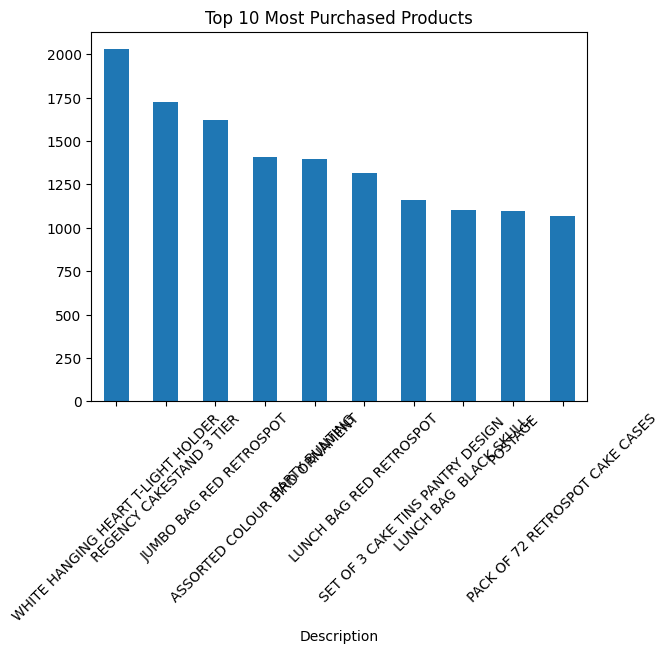

In [9]:
top_products = df['Description'].value_counts().head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title('Top 10 Most Purchased Products')
plt.xticks(rotation=45)
plt.show()

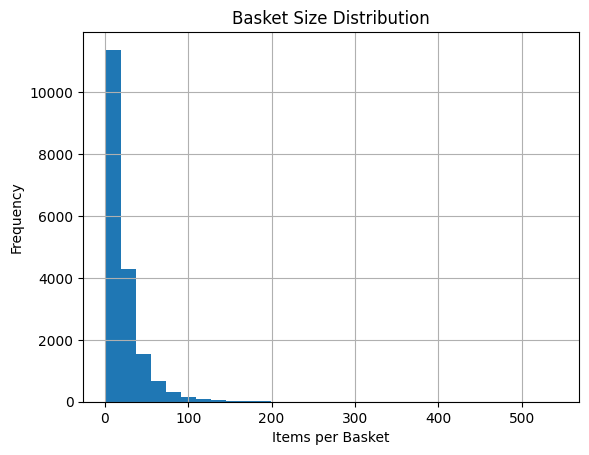

Average basket size: 21.467630556754425


In [10]:
basket_sizes = df.groupby('InvoiceNo').size()

plt.figure()
basket_sizes.hist(bins=30)
plt.title('Basket Size Distribution')
plt.xlabel('Items per Basket')
plt.ylabel('Frequency')
plt.show()

print("Average basket size:", basket_sizes.mean())

In [11]:
customer_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique()

multi_purchase_customers = (customer_transactions > 1).sum()

print("Customers with multiple purchases:", multi_purchase_customers)
print("Total customers:", df['CustomerID'].nunique())

Customers with multiple purchases: 2845
Total customers: 4339


## 4. Exploratory Data Analysis (EDA)

The exploratory data analysis revealed several important characteristics of the dataset:

- The dataset exhibits a **long-tail distribution**, where a small number of products are purchased very frequently while many others appear rarely.
- Basket sizes vary significantly across transactions, indicating diversity in customer purchasing behavior.
- Many customers have **multiple transactions**, which makes the dataset suitable for both co-occurrence analysis and sequential pattern mining.
- The dataset is heavily dominated by transactions from the **United Kingdom**, suggesting geographic concentration.
- The number of unique products is relatively large, which increases the complexity of pattern mining and may require careful selection of support thresholds.

These findings motivate the use of both **frequent itemset mining** and **sequential pattern mining**, as the dataset contains both co-occurrence and temporal purchasing structure.

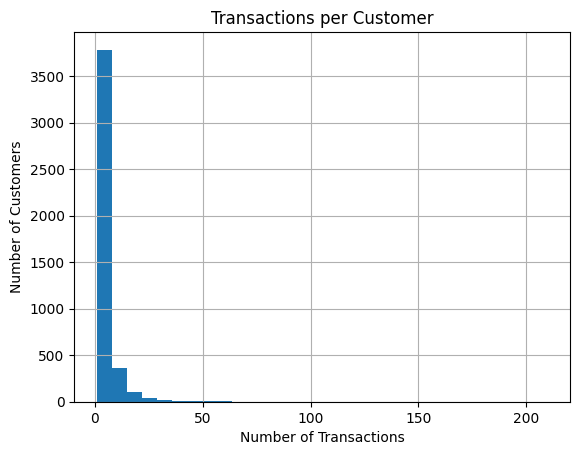

Avg transactions per customer: 4.271952062687255


In [12]:
customer_tx = df.groupby('CustomerID')['InvoiceNo'].nunique()

plt.figure()
customer_tx.hist(bins=30)
plt.title('Transactions per Customer')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.show()

print("Avg transactions per customer:", customer_tx.mean())

In [13]:
print("Number of unique products:", df['Description'].nunique())

Number of unique products: 3877


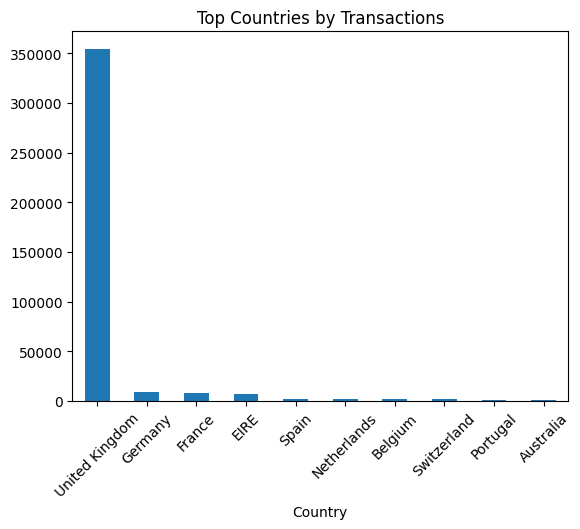

In [14]:
country_counts = df['Country'].value_counts()

plt.figure()
country_counts.head(10).plot(kind='bar')
plt.title('Top Countries by Transactions')
plt.xticks(rotation=45)
plt.show()

## 5. Research Questions

Based on what I observed during the EDA, this project focuses on understanding how products are purchased together and whether there are patterns over time in customer behavior. The following research questions build on those observations and combine both course methods and an external technique.

---

### RQ1: What frequent item combinations show up in transactions, and how do they change as we adjust the support threshold?

- **Task Type:** Frequent Itemset Mining  
- **Algorithms:** Apriori, FP-Growth  
- **Category:** Course Technique  
- **Evaluation Metrics:** Support, number of patterns, interpretability  

**Explanation:**  
From the EDA, it was clear that some products appear much more often than others. Because of this, I want to see how sensitive the results are to the support threshold. If the threshold is too high, we might only see very obvious patterns. If it’s lower, we might uncover more interesting combinations. This question helps explore that trade-off.

---

### RQ2: Which association rules are actually useful, and does lift give better insight than confidence alone?

- **Task Type:** Association Rule Mining  
- **Algorithms:** Apriori / FP-Growth + Association Rule Generation  
- **Category:** Course Technique  
- **Evaluation Metrics:** Confidence, lift, support, redundancy  

**Explanation:**  
Frequent itemsets tell us what appears together, but not how meaningful those relationships are. This question looks at association rules and compares confidence and lift to see which metric better captures real relationships between products. The goal is to avoid misleading rules that look strong but are actually common by chance.

---

### RQ3: Do customers show repeat or sequential purchasing patterns that we would miss if we only look at transactions individually?

- **Task Type:** Sequential Pattern Mining  
- **Algorithms:** PrefixSpan  
- **Category:** External Technique  
- **Evaluation Metrics:** Sequential support, interpretability, runtime  

**Explanation:**  
In the EDA, I noticed that many customers make multiple purchases over time. That made me curious whether there are patterns in the order of purchases. Standard market basket analysis ignores order, so this question explores whether sequential methods can uncover behaviors like repeat purchases or product progression.

## 6. RQ-to-Method Mapping

| RQ | Research Question | Task Type | Algorithm(s) | Category | Evaluation Metrics |
|----|------------------|----------|-------------|----------|--------------------|
| RQ1 | Frequent itemsets under varying support thresholds | Frequent Itemset Mining | Apriori, FP-Growth | Course | Support, pattern count, interpretability |
| RQ2 | Compare confidence vs lift in association rules | Association Rule Mining | Apriori/FP-Growth + Rule Generation | Course | Confidence, lift, support, redundancy |
| RQ3 | Sequential patterns in customer purchases | Sequential Pattern Mining | PrefixSpan | External | Sequential support, novelty, runtime |

## 7. Motivation and Feasibility

### Motivation

The EDA showed that this dataset has a lot of structure worth exploring. A small number of products appear very frequently, while many others are much less common, which suggests that customer purchasing behavior is not random. In addition, basket sizes vary and many customers make multiple purchases over time.

Because of this, it makes sense to study both:
- how products are bought together (co-occurrence patterns)
- how purchasing behavior evolves over time (sequential patterns)

These research questions aim to better understand both aspects of customer behavior rather than focusing on just one.

---

### Non-Triviality

These questions go beyond basic descriptive analysis. Simply counting product frequencies does not explain how items relate to each other or how purchasing behavior changes over time.

For example:
- Frequent itemsets identify co-occurring products, but do not indicate whether those relationships are meaningful.
- Association rules introduce metrics like confidence and lift, which require interpretation and comparison.
- Sequential pattern mining introduces ordering, which is completely ignored by traditional market basket analysis.

Because of this, the problem requires multiple techniques and thoughtful evaluation.

---

### Feasibility

This project is definitely doable for a few reasons:

- The dataset is already in a transactional format, making it suitable for itemset and rule mining.
- The data can be easily transformed into customer-level sequences for sequential analysis.
- Course algorithms like Apriori and FP-Growth are well-supported and straightforward to implement.
- External methods like PrefixSpan are available through Python libraries and can be applied once sequences are constructed.

Additionally, the EDA confirmed that:
- There are enough transactions to extract meaningful patterns.
- Many customers have multiple purchases, which makes sequence analysis possible.

---

### Risks and Challenges

There are a few challenges to keep in mind:

- **Computational cost:** Lower support thresholds may produce a very large number of itemsets.
- **Data sparsity:** Many products appear infrequently, which can make pattern discovery noisy.
- **Missing data:** Some customer IDs are missing, which limits sequence analysis.
- **Redundant patterns:** Association rules can become repetitive or difficult to interpret.
- **Parameter sensitivity:** Results may vary depending on support and confidence thresholds.

---

### Mitigation Strategies

To handle these challenges:

- Use reasonable support thresholds to balance performance and pattern discovery.
- Filter out extremely rare products if needed.
- Focus sequence analysis on customers with multiple transactions.
- Compare multiple evaluation metrics (e.g., confidence vs lift) to avoid misleading results.
- Test different parameter values before finalizing the analysis.

These steps help keep the methods practical while still producing meaningful insights.

## 8. Methodological Plan

### Data Preparation

Before running any algorithms, the dataset will be prepared slightly differently depending on the task.

- For frequent itemset and association rule mining, transactions will be grouped by invoice number to create baskets of products.
- For sequential pattern mining, transactions will be grouped by customer ID and sorted by invoice date to create ordered purchase sequences.
- If needed, I may also filter out very rare items or clean up duplicates to make the results easier to interpret.

---

### Course Methods

#### Frequent Itemset Mining
- **Algorithms:** Apriori and FP-Growth  

These methods will be used to find products that are commonly purchased together. I plan to test different support thresholds to see how the results change and to avoid only capturing the most obvious patterns.

---

#### Association Rule Mining
Association rules will be generated from the frequent itemsets.

The main focus will be comparing:
- **Confidence**, which shows how often a rule is correct  
- **Lift**, which shows whether the relationship is stronger than random chance  

This comparison will help determine which metric gives more meaningful insights.

---

### External Method

#### Sequential Pattern Mining
- **Algorithm:** PrefixSpan  

To apply this, transactions will be converted into ordered sequences based on each customer’s purchase history. This method will be used to explore whether there are patterns in the order of purchases that would not show up in standard basket analysis.

---

### Evaluation Plan

Each method will be evaluated based on how useful and interpretable the results are:

- **Frequent Itemsets:**
  - Support
  - Number of patterns found
  - Whether the item combinations make practical sense

- **Association Rules:**
  - Confidence
  - Lift
  - Redundancy of rules
  - Overall usefulness

- **Sequential Patterns:**
  - Sequential support
  - Interpretability
  - Whether new insights are found compared to itemsets
  - Runtime performance

---

### Baselines

To better understand the value of each method:

- High-support itemsets will be used as a baseline for pattern discovery.
- Rules ranked only by confidence will be compared with those ranked by lift.
- Standard (unordered) basket analysis will be used as a baseline when evaluating sequential patterns.

---

### Initial Feasibility Checks

Before running the full analysis, I will do a few small tests to make sure everything is working correctly:

- Run Apriori or FP-Growth on a small subset to confirm the basket format is correct.
- Verify that customer transactions can be grouped and sorted properly for sequence creation.
- Test a small example of sequential pattern mining to make sure the implementation works.

These steps help confirm that the approach is working before scaling up to the full dataset.

In [15]:
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'] \
           .sum().unstack().fillna(0)

basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()

/tmp/ipykernel_1029/2749691624.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
df_sorted = df.sort_values(['CustomerID', 'InvoiceDate'])

sequences = df_sorted.groupby('CustomerID')['Description'].apply(list)

sequences.head()

,Description
CustomerID,
12346.0,[MEDIUM CERAMIC TOP STORAGE JAR]
12347.0,"[BLACK CANDELABRA T-LIGHT HOLDER, AIRLINE BAG ..."
12348.0,"[72 SWEETHEART FAIRY CAKE CASES, 60 CAKE CASES..."
12349.0,"[PARISIENNE CURIO CABINET, SWEETHEART WALL TID..."
12350.0,"[CHOCOLATE THIS WAY METAL SIGN, METAL SIGN NEI..."


## 9. Collaboration Declaration

### Collaborators
I completed this project independently and did not collaborate with any other students.

---

### Web Sources
The following resources were used to support understanding and implementation:

- Pandas documentation (https://pandas.pydata.org/)
- mlxtend documentation for Apriori and association rules (https://rasbt.github.io/mlxtend/)
- General Python and data mining references as needed

---

### AI Tools
I used ChatGPT in a limited way to help with organizing sections and refining some explanations. All ideas, coding decisions, and implementations were developed and executed by me.

---

### Papers / References
The following foundational works are relevant to the methods used:

- Agrawal, R., & Srikant, R. (1994). *Fast Algorithms for Mining Association Rules*
- Han, J., Pei, J., & Yin, Y. (2000). *Mining Frequent Patterns without Candidate Generation*
- Pei, J., Han, J., et al. (2001). *PrefixSpan: Mining Sequential Patterns Efficiently by Prefix-Projected Pattern Growth*